In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import torchvision.datasets as datasets
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
from torch.optim.lr_scheduler import StepLR
from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter

from typing import Dict, Tuple
from tqdm import tqdm
import numpy as np
import time
import os
import random
from tabulate import tabulate

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

%matplotlib inline

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")



Torch version: 2.7.0+cu126
CUDA available: True
CUDA version: 12.6
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090


In [8]:
from waveguide_dataset_paired import WaveguideDatasetPaired
dataset = WaveguideDatasetPaired('train_test_split.h5')

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net4_ModeOnly_TiledConditioning(nn.Module):
    def __init__(self):
        super().__init__()

        # ---------- Initial Conv Layers (before tiling) ----------
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)   # → [B, 64, 32, 32]
        self.gn1   = nn.GroupNorm(8, 64)
        
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1) # → [B, 128, 16, 16]
        self.gn2   = nn.GroupNorm(8, 128)
        
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1) # → [B, 256, 8, 8]
        self.gn3   = nn.GroupNorm(8, 256)

        self.pool = nn.MaxPool2d(2, 2)

        # ---------- Convs after tiling (input: [B, 256 + 4, 8, 8]) ----------
        self.conv4 = nn.Conv2d(260, 256, 3, padding=1)
        self.gn4   = nn.GroupNorm(8, 256)
        
        self.conv5 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn5   = nn.GroupNorm(8, 256)

        self.conv6 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn6   = nn.GroupNorm(8, 256)

        self.conv7 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn7   = nn.GroupNorm(8, 256)

        self.conv8 = nn.Conv2d(256, 256, 3, padding=1)
        self.gn8   = nn.GroupNorm(8, 256)

        # ---------- Fully Connected Layers ----------
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)

        self.act = nn.GELU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_img, x_cond):
        """
        x_img:  [B, 1, 32, 32]
        x_cond: [B, 4]
        """

        # Initial conv + pooling stages
        x = self.pool(self.act(self.gn1(self.conv1(x_img))))   # → [B, 64, 16, 16]
        x = self.pool(self.act(self.gn2(self.conv2(x))))       # → [B, 128, 8, 8]
        x = self.act(self.gn3(self.conv3(x)))                  # → [B, 256, 8, 8]

        # Tile conditioning to 8x8
        cond = x_cond.unsqueeze(-1).unsqueeze(-1)              # [B, 4, 1, 1]
        cond_tiled = cond.expand(-1, -1, 8, 8)                 # [B, 4, 8, 8]

        # Concatenate along channel axis
        x = torch.cat([x, cond_tiled], dim=1)                  # [B, 260, 8, 8]

        # Deeper conv stack
        x = self.act(self.gn4(self.conv4(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn5(self.conv5(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn6(self.conv6(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn7(self.conv7(x)))                  # [B, 256, 8, 8]
        x = self.act(self.gn8(self.conv8(x)))                  # [B, 256, 8, 8]

        # Fully connected prediction head
        x = x.view(x.size(0), -1)                              # [B, 256*8*8 = 16384]
        x = self.dropout(self.act(self.fc1(x)))                # [B, 512]
        x = self.dropout(self.act(self.fc2(x)))                # [B, 128]
        out = self.fc3(x)                                      # [B, 1]

        return out


In [10]:
def train_structured(model, device, loader, optimizer, loss_fn):
    """
    Train for one epoch on structured [4,2] mode-weight inputs.

    · model takes:   waveguide, params
    · model outputs: [mode0, weight0]
    · target:        cond[0] (mode0, weight0), extracted from the [4,2] tensor
    """
    model.train()

    for cond, params, waveguide in loader:
        cond, params, waveguide = (
            cond.to(device),       # [B, 4, 2]
            params.to(device),     # [B, 4]
            waveguide.to(device),  # [B, 1, 32, 32]
        )

        # ✂ Extract mode0 and weight0 as target from cond[:, 0]
        y_true = cond[:, 0, 0].unsqueeze(1)  # shape [B, 1]

        # forward pass
        optimizer.zero_grad()
        y_pred = model(waveguide, params)  # shape [B, 2]
        loss = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer.step()

In [11]:
def test_structured(model, device, loader, loss_fn, dataset, epoch_num, total_epochs):
    """
    Evaluate model for one epoch using [B, 4, 2] structured mode-weight targets.

    * Model outputs:   [B, 1] (mode-0 only)
    * Ground truth:    [B, 4, 2]; we slice [:, 0, 0] for the first mode

    Returns
    -------
    float
        Average MSE loss over the test set.
    """
    model.eval()
    total_loss = 0.0
    collected  = []

    # scalar stats for inverse normalization
    mode_mean_log = float(dataset.meanm[0])
    mode_std_log  = float(dataset.stdm[0])

    with torch.no_grad():
        for cond, params, waveguide in loader:
            cond, params, waveguide = (
                cond.to(device),       # [B, 4, 2]
                params.to(device),     # [B, 4]
                waveguide.to(device),  # [B, 1, 32, 32]
            )

            # Extract only mode0 target: shape [B, 1]
            y_true = cond[:, 0, 0].unsqueeze(1)

            # Predict: shape [B, 1]
            y_pred = model(waveguide, params)

            batch_loss = loss_fn(y_pred, y_true).item()
            total_loss += batch_loss * waveguide.size(0)

            # Collect samples for plotting
            for t, o, p in zip(y_true.cpu(), y_pred.cpu(), params.cpu()):
                if len(collected) < 50:
                    t_mode0_log = t.item() * mode_std_log + mode_mean_log
                    o_mode0_log = o.item() * mode_std_log + mode_mean_log
                    t_mode0 = np.expm1(t_mode0_log)
                    o_mode0 = np.expm1(o_mode0_log)

                    collected.append((
                        t_mode0,
                        o_mode0,
                        p.numpy()
                    ))

    avg_loss = total_loss / len(loader.dataset)

    # Plot on last epoch
    if epoch_num == total_epochs - 1 and collected:
        chosen = random.sample(collected, 8)
        fig, ax = plt.subplots(figsize=(6, 4))

        for tgt, out, prm in chosen:
            ax.plot([0], [tgt], 'ro')   # target
            ax.plot([0], [out], 'bx')   # output

        ax.set_title("Mode-0 Prediction")
        ax.set_xticks([0])
        ax.set_xticklabels(['value'])
        ax.grid(True)

        plt.suptitle("Targets (red) vs Outputs (blue) on last epoch")
        plt.tight_layout()
        plt.show()

    return avg_loss


Training, loss: 0.0119:  99%|█████████▉| 99/100 [1:50:53<01:07, 67.09s/it]

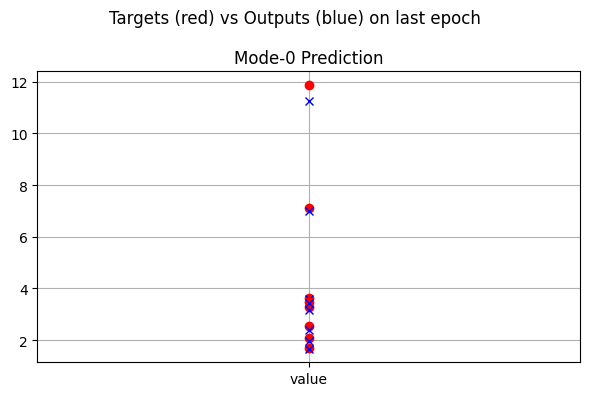

Training, loss: 0.0119: 100%|██████████| 100/100 [1:52:00<00:00, 67.21s/it]


In [12]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import torch.nn as nn

def main(dataset):
    os.makedirs("models", exist_ok=True)
    
    # --- Training Configuration ---
    batch_size = 512
    test_batch_size = 1000
    lr = 1e-3
    gamma = 0.9
    epochs = 100
    save_dir = 'only_first_mode_no_weight'
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # --- Model & Optimizer ---
    model = Net4_ModeOnly_TiledConditioning().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.MSELoss()

    # --- Dataset Split ---
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False, num_workers=8)

    # --- Training Loop ---
    e_loss_graph = []
    pbar = tqdm(range(epochs), desc="Training, loss= ----")
    best = 100
    for epoch in pbar:
        train_structured(model, device, train_loader, optimizer, loss_fn)
        e_loss = test_structured(model, device, test_loader, loss_fn, dataset, epoch, epochs)
        e_loss_graph.append(e_loss)

        # Update progress bar description
        pbar.set_description(f"Training, loss: {e_loss:.4f}")

        # Scheduler step and save model
        scheduler.step()
        if best > e_loss:
            torch.save(model.state_dict(), f"models/{save_dir}.pth")
        
        # Save updated loss plot
        plt.figure()
        plt.plot(range(epoch + 1), e_loss_graph, label="Test Loss")
        plt.title(f"Test Loss Over Epochs ({save_dir})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"models/{save_dir}.png")
        plt.close()

if __name__ == '__main__':
    main(dataset)
